
<div dir=ltr align=center>

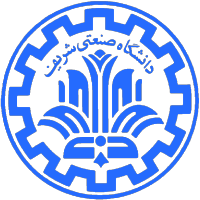

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: Gaussian Mixture Model <br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [28]:
student_number = 'Narges Kari'
full_name = '402110821'

# Customer Segmentation Using GMM

## Description:
In this project, you will implement a Gaussian Mixture Model (GMM) from scratch and use it to perform customer segmentation based on demographic and behavioral data. Customer segmentation is the process of grouping customers into clusters such that customers within the same cluster are more similar to each other than to those in other clusters. In this assignment, segmentation is done using a probabilistic clustering approach, where each customer is assigned a probability of belonging to each cluster based on features such as Age, Annual Income, and Spending Score.

**⚠️ Notice:** You are allowed to use only the imported libraries and must follow the provided function structure.

# 📝 **Project Instructions**

1. **Load the customer dataset**  
   Load the dataset containing customer information such as **Age, Annual Income, Spending Score**, and optionally **Gender**.

2. **Feature selection**  
    Anything that you need.

3. **Standardize features**  
   Normalize the numerical features using **standardization** so that each feature has **mean 0 and standard deviation 1**.

4. **Initialize GMM parameters**  
   Randomly initialize **cluster weights, means, and covariance matrices** for a chosen number of clusters **K**.

5. **Expectation-Maximization (EM) steps**  
   - **Expectation step:** Compute the **responsibility** of each cluster for every customer.  
   - **Maximization step:** Update **weights, means, and covariances** based on responsibilities.  
   - Repeat until **log-likelihood converges** or **max iterations** is reached.

6. **Multiple initializations**  
   Run the GMM algorithm **multiple times** with different random seeds and select the model with the **highest log-likelihood** to avoid poor local minima.

7. **Select the optimal number of clusters**  
   Compute **BIC (Bayesian Information Criterion)** for different values of **K** and choose the one with the **lowest BIC**.

8. **Assign clusters to customers**  
   For the final model, assign each customer to the cluster with the **highest responsibility**.

9. **Visualize clusters**  
   - **2D scatter plots:** Plot feature pairs (e.g., Age vs Income, Age vs Spending Score) with points colored by cluster.  
   - **Cluster centroids and circles:** Highlight **cluster centers** and **spread** using semi-transparent colored circles.  
   - **3D scatter plot:** Visualize clusters in 3D with **centroids marked**.



# 📤 **Expected Output**

- A **clustered customer dataset** showing each customer assigned to a **GMM cluster**  
- **2D scatter plots** of feature pairs (e.g., Age vs Income, Age vs Spending Score, Income vs Spending Score) with:  
  - Cluster points colored by cluster  
  - **Centroids** marked  
  - **Semi-transparent circles** showing cluster spread  
- A **3D scatter plot** visualizing all three features with cluster centroids highlighted  
- A **BIC vs. K plot** showing the Bayesian Information Criterion for different numbers of clusters, helping identify the **optimal K**  
- **Observe** which features distinguish clusters and how changing **K** affects segmentation quality


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle
from scipy.stats import multivariate_normal

In [30]:
# read data

df = pd.read_csv('Mall_Customers.csv')
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [31]:
# data prepration (feature selection and scaling)

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

def standard_scale(X):
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds

X_scaled, means_X, stds_X = standard_scale(X)


In [32]:
# GMM from scratch

def gaussian_pdf_all(X, mean, cov):
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    d = X.shape[1]
    norm_const = -0.5 * d * np.log(2 * np.pi) - 0.5 * np.log(np.linalg.det(cov))
    diff = X - mean
    exponent = -0.5 * np.sum(diff * np.linalg.solve(cov, diff.T).T, axis=1)

    return np.exp(norm_const + exponent)

def initialize_parameters(X, k, rng):
    n, d = X.shape
    weights = np.ones(k) / k
    random_indices = rng.choice(n, k, replace=False)
    means = X[random_indices]
    initial_cov = np.cov(X, rowvar=False)
    covs = np.array([initial_cov] * k)

    return weights, means, covs

def expectation_step(X, weights, means, covs):
    n, d = X.shape
    k = len(weights)
    weighted_pdfs = np.zeros((n, k))
    for j in range(k):
        weighted_pdfs[:, j] = weights[j] * multivariate_normal.pdf(X, means[j], covs[j], allow_singular=True)
    sum_weighted_pdfs = np.sum(weighted_pdfs, axis=1, keepdims=True)
    resp = weighted_pdfs / (sum_weighted_pdfs + 1e-10)

    return resp

def maximization_step(X, resp):
    n, d = X.shape
    k = resp.shape[1]
    Nk = np.sum(resp, axis=0)
    weights = Nk / n
    means = np.dot(resp.T, X) / Nk[:, np.newaxis] # (k, n) @ (n, d) -> (k, d)
    covs = np.zeros((k, d, d))
    for j in range(k):
        if Nk[j] > 1e-6:
            diff = X - means[j]
            covs[j] = np.dot(resp[:, j] * diff.T, diff) / Nk[j]
            covs[j] += 1e-6 * np.eye(d)
        else:
             covs[j] = np.cov(X, rowvar=False) + 1e-6 * np.eye(d)

    return weights, means, covs

def compute_log_likelihood(X, weights, means, covs):
    n, d = X.shape
    k = len(weights)
    weighted_pdfs = np.zeros((n, k))
    for j in range(k):
        weighted_pdfs[:, j] = weights[j] * multivariate_normal.pdf(X, means[j], covs[j], allow_singular=True)
    likelihoods = np.sum(weighted_pdfs, axis=1)
    ll = np.sum(np.log(likelihoods + 1e-10))

    return ll

def gmm_train(X, k, max_iter=200, tol=1e-4, seed=None):
    rng = np.random.RandomState(seed)
    weights, means, covs = initialize_parameters(X, k, rng)
    log_likelihoods = []
    for i in range(max_iter):
        resp = expectation_step(X, weights, means, covs)
        weights, means, covs = maximization_step(X, resp)
        ll = compute_log_likelihood(X, weights, means, covs)
        log_likelihoods.append(ll)
        if i > 0 and np.abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break

    return weights, means, covs, resp, ll

In [33]:
def compute_bic(ll, k, n, d):
    num_params = k * (d + d * (d + 1) // 2) + (k - 1)
    bic = -2 * ll + num_params * np.log(n)
    return bic
n, d = X_scaled.shape
bic_values = []
k_range = range(2, 9)
best_models = {}
max_runs = 5
best_bic = np.inf
best_k = 0

for k in k_range:
    best_ll = -np.inf
    best_model_k = None
    for run in range(max_runs):
        weights, means, covs, resp, ll = gmm_train(X_scaled, k, seed=run)

        if ll > best_ll:
            best_ll = ll
            best_model_k = (weights, means, covs, resp, ll)
    ll = best_model_k[-1]
    bic = compute_bic(ll, k, n, d)
    bic_values.append(bic)
    best_models[k] = best_model_k
    print(f"  k={k}: Log-Likelihood = {ll:.2f}, BIC = {bic:.2f}")
    if bic < best_bic:
        best_bic = bic
        best_k = k

print("\nBest k =", best_k)

  k=2: Log-Likelihood = -777.75, BIC = 1656.16
  k=3: Log-Likelihood = -714.11, BIC = 1581.87
  k=4: Log-Likelihood = -684.77, BIC = 1576.18
  k=5: Log-Likelihood = -658.42, BIC = 1576.45
  k=6: Log-Likelihood = -642.27, BIC = 1597.14
  k=7: Log-Likelihood = -628.27, BIC = 1622.12
  k=8: Log-Likelihood = -615.16, BIC = 1648.89

Best k = 4


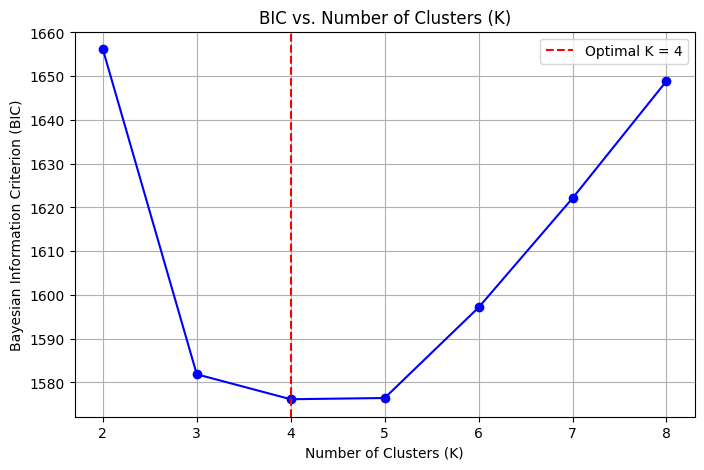

In [34]:
# BIC plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, bic_values, marker='o', linestyle='-', color='b')
plt.axvline(best_k, color='r', linestyle='--', label=f'Optimal K = {best_k}')
plt.title('BIC vs. Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# train final model
final_weights, final_means_scaled, final_covs_scaled, final_resp, final_ll = best_models[best_k]

df['Cluster_GMM'] = np.argmax(final_resp, axis=1)

final_means = final_means_scaled * stds_X + means_X

feature_names = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


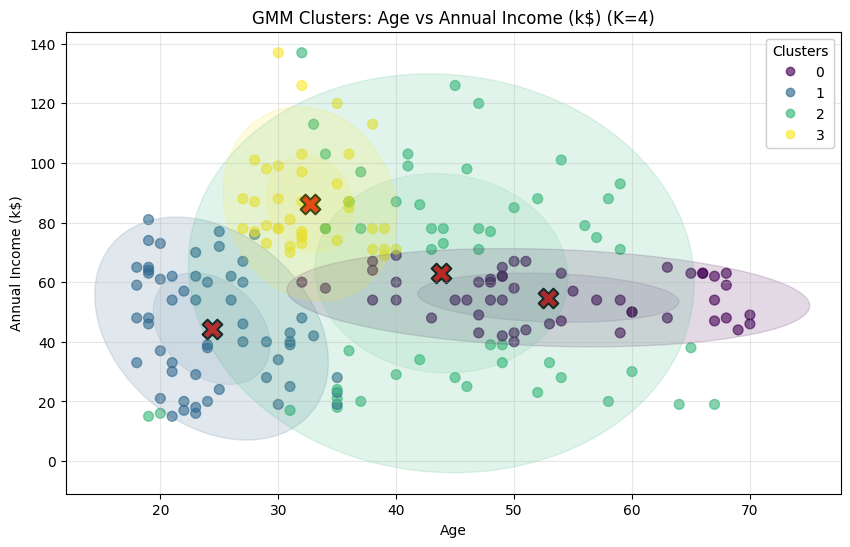

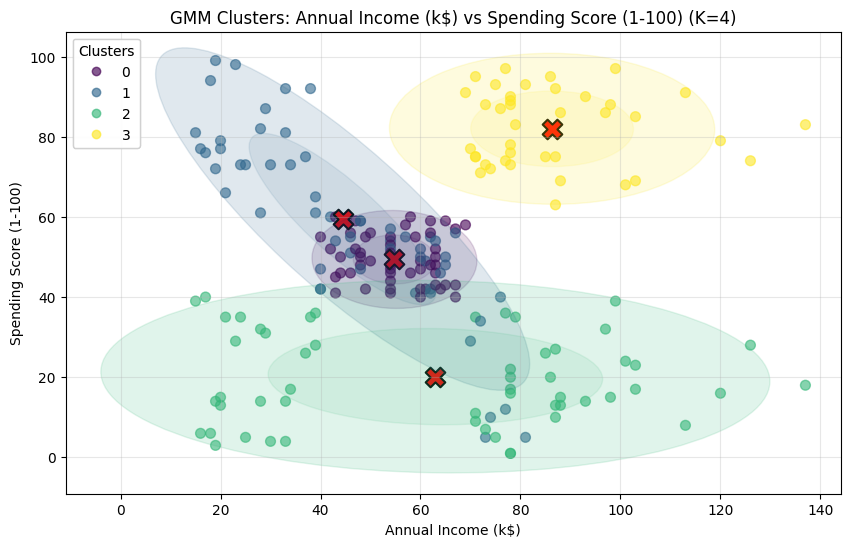

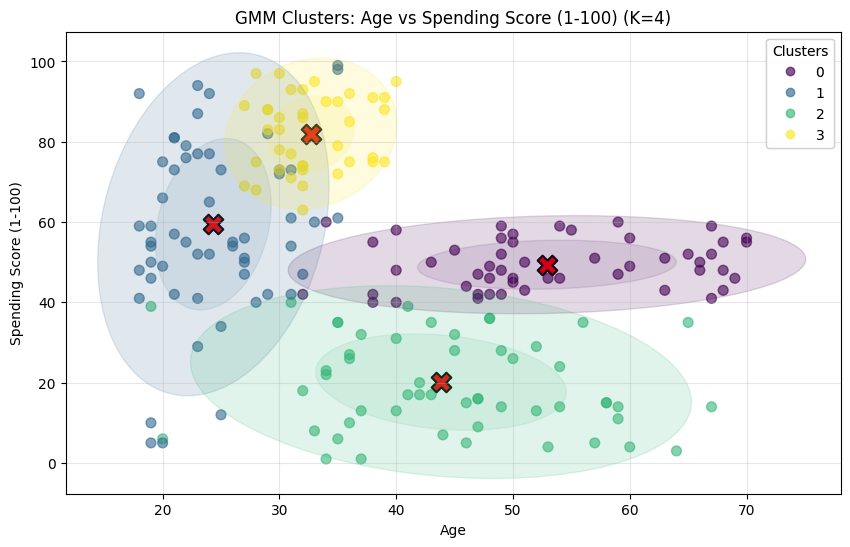

In [36]:
# 2D plot with cluster circles and centroid
for i, j in [(0, 1), (1, 2), (0, 2)]:  # <--- جفت (0, 2) اضافه شد
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df.iloc[:, i+2], df.iloc[:, j+2], c=df['Cluster_GMM'], cmap='viridis', s=50, alpha=0.6)
    plt.scatter(final_means[:, i], final_means[:, j], marker='X', s=200, c='red', label='Centroids', edgecolor='black', linewidth=1.5)
    olors = plt.colormaps['viridis'](np.linspace(0, 1, best_k))
    ax = plt.gca()

    for k_idx in range(best_k):
        cov_2d_scaled = final_covs_scaled[k_idx, :, :][np.ix_([i, j], [i, j])]
        stds_2d = np.array([stds_X[i], stds_X[j]])
        D_2d = np.diag(stds_2d)
        cov_2d_original = D_2d @ cov_2d_scaled @ D_2d.T
        eigenvalues, eigenvectors = np.linalg.eigh(cov_2d_original)
        order = eigenvalues.argsort()[::-1]
        eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
        from matplotlib.patches import Ellipse
        for factor in [1.0, 2.0]:
            ellipse = Ellipse(xy=final_means[k_idx, [i, j]],
                              width=np.sqrt(eigenvalues[0]) * 2 * factor,
                              height=np.sqrt(eigenvalues[1]) * 2 * factor,
                              angle=angle,
                              edgecolor=colors[k_idx],
                              facecolor=colors[k_idx],
                              alpha=0.1 + (0.05 * (factor-1)))
            ax.add_patch(ellipse)


    plt.title(f'GMM Clusters: {feature_names[i]} vs {feature_names[j]} (K={best_k})')
    plt.xlabel(feature_names[i])
    plt.ylabel(feature_names[j])
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)
    plt.grid(True, alpha=0.3)
    plt.show()

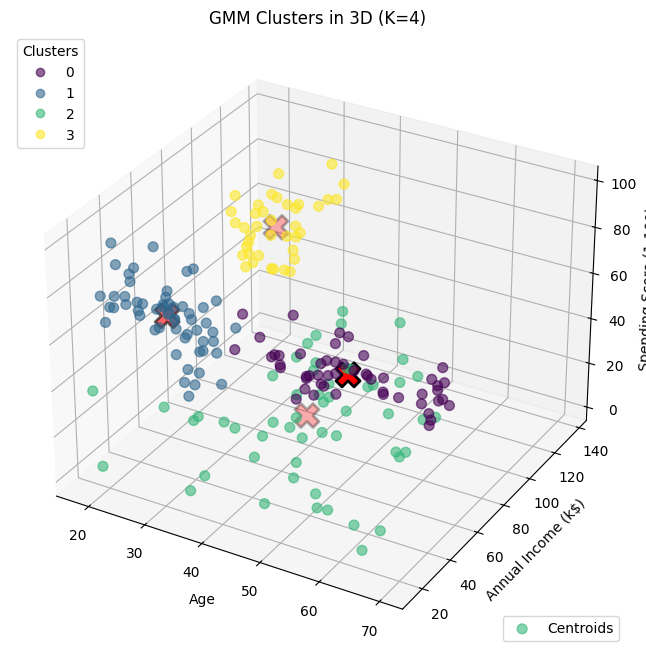

In [37]:
# 3D plot with cluster centroids
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# رسم نقاط داده خوشه‌بندی شده
scatter_3d = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                        c=df['Cluster_GMM'], cmap='viridis', s=50, alpha=0.6)

ax.scatter(final_means[:, 0], final_means[:, 1], final_means[:, 2],
           marker='X', s=300, c='red', label='Centroids', edgecolor='black', linewidth=2.0)

ax.set_title(f'GMM Clusters in 3D (K={best_k})')
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.set_zlabel(feature_names[2])

legend = ax.legend(*scatter_3d.legend_elements(), title="Clusters", loc='upper left')
ax.add_artist(legend)
ax.legend(['Centroids'], loc='lower right')

plt.show()


In [44]:
# save segmented result
df['Cluster_GMM'] = np.argmax(final_resp, axis=1)
segmented_df = df[['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre', 'Cluster_GMM']].copy()
output_file_name = 'Mall_Customers_GMM_Clustered.csv'
segmented_df.to_csv(output_file_name, index=False)

In [45]:
# Your first 10 row shoud be like :
df = pd.read_csv('Mall_Customers_GMM_Clustered.csv')
df.head(10)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre,Cluster_GMM
0,1,19,15,39,Male,2
1,2,21,15,81,Male,1
2,3,20,16,6,Female,2
3,4,23,16,77,Female,1
4,5,31,17,40,Female,2
5,6,22,17,76,Female,1
6,7,35,18,6,Female,2
7,8,23,18,94,Female,1
8,9,64,19,3,Male,2
9,10,30,19,72,Female,1
